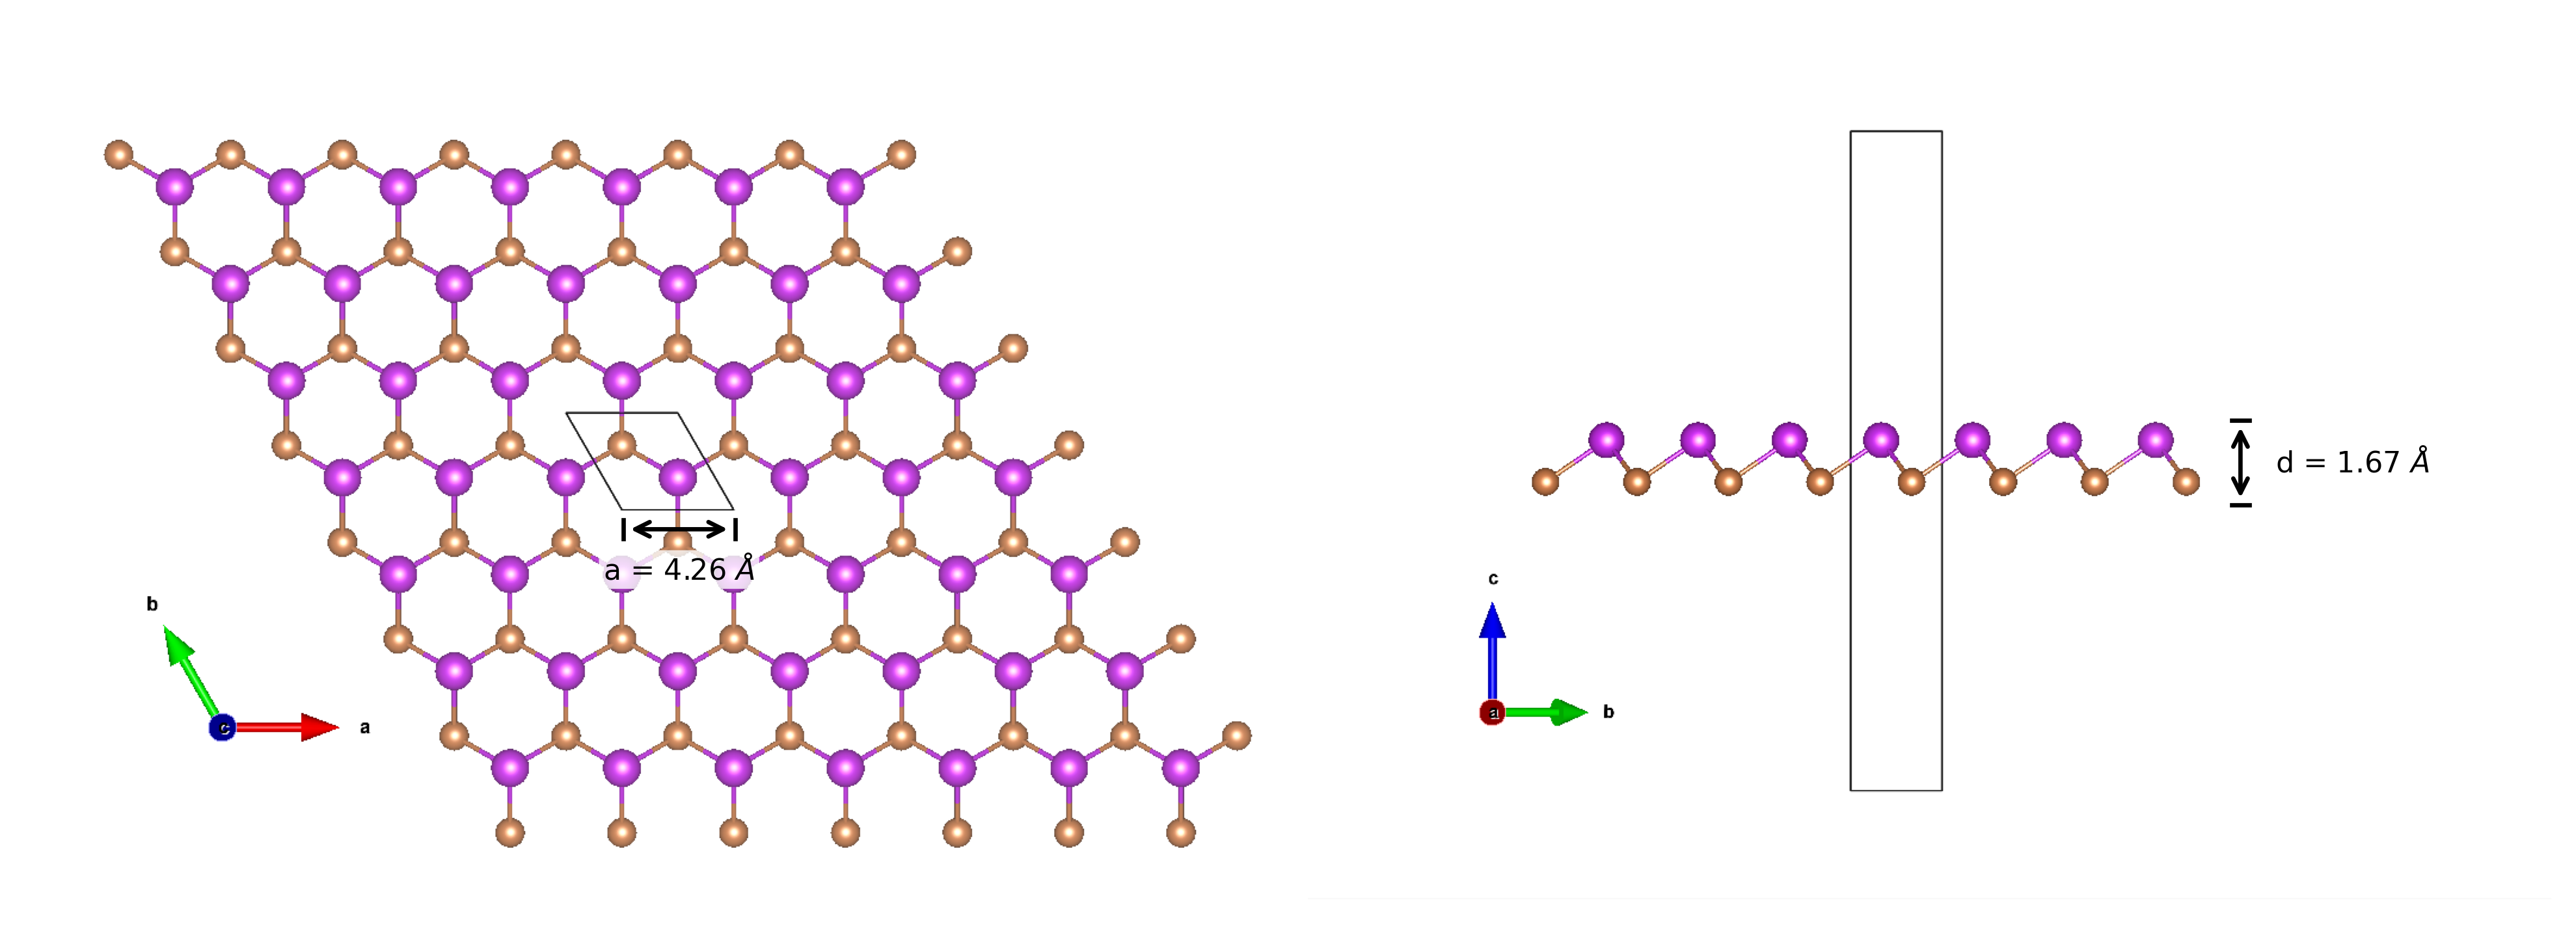

Saved → BiSb_monolayer.png


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

im1 = Image.open("a.png")
im2 = Image.open("b.png")

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=400)

ax[0].imshow(im1)
ax[1].imshow(im2)
ax[0].axis("off")
ax[1].axis("off")


def draw_arrow(ax, x1, y1, x2, y2, color="black", lw=1.2, ticks=True, tick_len=8):
    """
    Draw a double-headed arrow from (x1, y1) to (x2, y2) in pixel coordinates.

    Parameters
    ----------
    ax        : matplotlib Axes
    x1, y1   : start point (pixels)
    x2, y2   : end point (pixels)
    color     : arrow color
    lw        : line width
    ticks     : whether to draw small perpendicular tick marks at each end
    tick_len  : half-length of tick marks in pixels
    """
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                xycoords="data", textcoords="data",
                arrowprops=dict(arrowstyle="<->", color=color, lw=lw))

    if ticks:
        # Perpendicular direction
        dx, dy = x2 - x1, y2 - y1
        length = np.hypot(dx, dy)
        px, py = -dy / length * tick_len, dx / length * tick_len
        for xk, yk in [(x1, y1), (x2, y2)]:
            ax.plot([xk - px, xk + px], [yk - py, yk + py], color=color, lw=lw)


def draw_label(ax, x, y, text, color="black", fontsize=7, ha="center", va="center",
               bg=True, bg_alpha=0.8):
    """
    Draw a text label at (x, y) in pixel coordinates.

    Parameters
    ----------
    ax        : matplotlib Axes
    x, y      : position (pixels)
    text      : label string (LaTeX supported, e.g. r'$\\Delta$')
    color     : text color
    fontsize  : font size
    ha, va    : horizontal / vertical alignment
    bg        : whether to draw a white background box behind the text
    bg_alpha  : opacity of the background box
    """
    bbox = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=bg_alpha) if bg else None
    ax.text(x, y, text, color=color, fontsize=fontsize,
            ha=ha, va=va, bbox=bbox)


# ── Image dimensions ────────────────────────────────────────────────────────
h1, w1 = np.array(im1).shape[:2]
h2, w2 = np.array(im2).shape[:2]

# ════════════════════════════════════════════════════════════════════
# LEFT IMAGE — top view

# Lattice constant 'a'  (horizontal arrow)
lc_y  = h1 * 0.56
lc_x1 = w1 * 0.48
lc_x2 = w1 * 0.57
draw_arrow(ax[0], lc_x1, lc_y, lc_x2, lc_y, color="#000000")
draw_label(ax[0], (lc_x1 + lc_x2) / 2, lc_y + lc_y * 0.08, r'a = 4.26 $\AA$', color="#000000", fontsize=8)

# ════════════════════════════════════════════════════════════════════
# RIGHT IMAGE — side view

# Buckling distance Δ  (vertical arrow)
bk_x  = w2 * 0.75
bk_y1 = h2 * 0.435
bk_y2 = h2 * 0.535
draw_arrow(ax[1], bk_x, bk_y1, bk_x, bk_y2, color="#000000")
draw_label(ax[1], bk_x*1.12, (bk_y1 + bk_y2) / 2, r"d = 1.67 $\AA$", color="#000000", fontsize=8)

plt.tight_layout()
plt.savefig("BiSb_monolayer.png", bbox_inches="tight", dpi=400)
plt.show()
print("Saved → BiSb_monolayer.png")

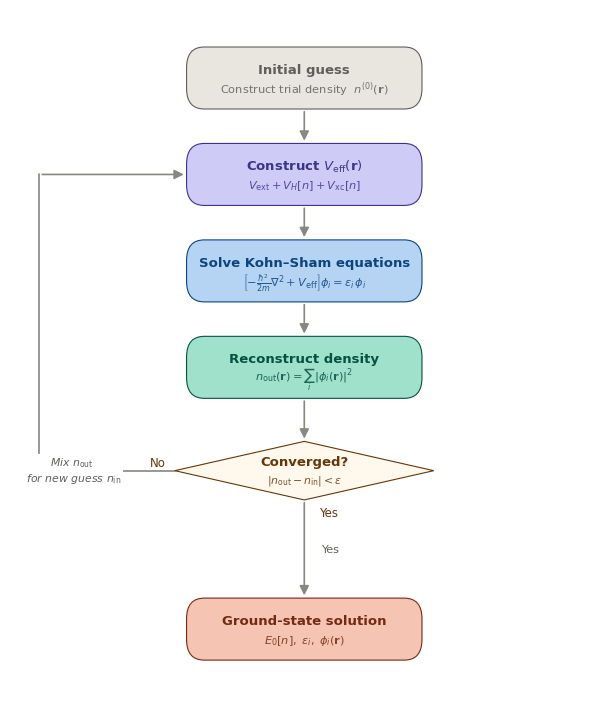

In [12]:
"""
Kohn-Sham SCF Cycle Schematic
Plots the self-consistent field loop as a publication-quality flowchart.
Dependencies: matplotlib, numpy
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np

# ── colour palette ────────────────────────────────────────────────────────────
GRAY   = ("#E8E6DF", "#5F5E5A")   # (fill, text)
PURPLE = ("#CECBF6", "#3C3489")
BLUE   = ("#B5D4F4", "#0C447C")
TEAL   = ("#9FE1CB", "#085041")
CORAL  = ("#F5C4B3", "#712B13")
DIAM   = ("#FFF8ED", "#633806")   # decision diamond (amber-ish)

ARROW_COLOR  = "#888780"
BORDER_COLOR = "#B4B2A9"
BG_COLOR     = "white"
FONT         = "DejaVu Sans"

# ── layout constants ──────────────────────────────────────────────────────────
FIG_W, FIG_H = 6, 7
CX   = 0.50        # centre x for main column
BW   = 0.4         # box width  (axes fraction)
BH   = 0.09        # box height
GAP  = 0.05        # vertical gap between boxes
PAD  = 0.012       # inner text padding

# y-centres of each main box (top → bottom)
Y = {}
Y["init"]    = 0.90
Y["veff"]    = Y["init"]  - BH - GAP
Y["ks"]      = Y["veff"]  - BH - GAP
Y["density"] = Y["ks"]    - BH - GAP
Y["conv"]    = Y["density"]- BH - GAP - 0.01   # diamond sits lower
Y["output"]  = 0.1

# ── helpers ───────────────────────────────────────────────────────────────────

def rounded_box(ax, cx, cy, w, h, fill, edge, label, sublabel=None, r=0.03):
    """Draw a rounded rectangle with a bold title and optional subtitle."""
    x = cx - w / 2
    y = cy - h / 2
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0,rounding_size={r}",
        linewidth=0.8, edgecolor=edge, facecolor=fill,
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(box)
    if sublabel:
        ax.text(cx, cy + h * 0.14, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
        ax.text(cx, cy - h * 0.18, sublabel,
                ha="center", va="center",
                fontsize=8.2, color=edge, alpha=0.85,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
    else:
        ax.text(cx, cy, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def diamond(ax, cx, cy, w, h, fill, edge, label, sublabel=None):
    """Draw a diamond (decision) shape."""
    hw, hh = w / 2, h / 2
    xs = [cx, cx + hw, cx, cx - hw, cx]
    ys = [cy + hh, cy, cy - hh, cy, cy + hh]
    coords = list(zip(xs, ys))
    patch = plt.Polygon(
        coords, closed=True,
        linewidth=0.8, edgecolor=edge, facecolor=fill,
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(patch)
    if sublabel:
        ax.text(cx, cy + hh * 0.32, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
        ax.text(cx, cy - hh * 0.32, sublabel,
                ha="center", va="center",
                fontsize=7.8, color=edge, alpha=0.85,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
    else:
        ax.text(cx, cy, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def arrow(ax, x1, y1, x2, y2, label=None, label_side="right"):
    """Draw a straight arrow between two axes-fraction points."""
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=ARROW_COLOR,
            lw=1.2,
            mutation_scale=14,
        ),
        zorder=2
    )
    if label:
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        dx = 0.03 if label_side == "right" else -0.03
        ax.text(mx + dx, my, label,
                ha="left" if label_side == "right" else "right",
                va="center", fontsize=8, color="#5F5E5A",
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def polyline_arrow(ax, points, label=None, label_pos=0.5):
    """Draw a multi-segment arrow through a list of (x,y) axes-fraction points."""
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax.plot(xs[:-1], ys[:-1], color=ARROW_COLOR, lw=1.2,
            transform=ax.transAxes, zorder=2, solid_capstyle="round")
    ax.annotate(
        "", xy=points[-1], xytext=points[-2],
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=ARROW_COLOR,
            lw=1.2,
            mutation_scale=14,
        ),
        zorder=2
    )
    if label:
        idx = max(0, int(len(points) * label_pos) - 1)
        lx = (xs[idx] + xs[idx + 1]) / 2 - 0.06
        ly = (ys[idx] + ys[idx + 1]) / 2
        ax.text(lx, ly, label,
                ha="center", va="center",
                fontsize=7.8, color="#5F5E5A", style="italic",
                fontfamily=FONT, transform=ax.transAxes,
                bbox=dict(facecolor=BG_COLOR, edgecolor="none", pad=1.5),
                zorder=5)


# ── figure ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ── boxes ─────────────────────────────────────────────────────────────────────

# 1. Initial guess
rounded_box(ax, CX, Y["init"], BW, BH,
            fill=GRAY[0], edge=GRAY[1],
            label="Initial guess",
            sublabel=r"Construct trial density  $n^{(0)}(\mathbf{r})$")

# 2. Construct V_eff
rounded_box(ax, CX, Y["veff"], BW, BH,
            fill=PURPLE[0], edge=PURPLE[1],
            label=r"Construct $V_\mathrm{eff}(\mathbf{r})$",
            sublabel=r"$V_\mathrm{ext} + V_H[n] + V_\mathrm{xc}[n]$")

# 3. Solve KS equations
rounded_box(ax, CX, Y["ks"], BW, BH,
            fill=BLUE[0], edge=BLUE[1],
            label="Solve Kohn–Sham equations",
            sublabel=r"$\left[-\frac{\hbar^2}{2m}\nabla^2 + V_\mathrm{eff}\right]\phi_i = \varepsilon_i\,\phi_i$")

# 4. Reconstruct density
rounded_box(ax, CX, Y["density"], BW, BH,
            fill=TEAL[0], edge=TEAL[1],
            label="Reconstruct density",
            sublabel=r"$n_\mathrm{out}(\mathbf{r}) = \sum_i |\phi_i(\mathbf{r})|^2$")

# 5. Convergence diamond
DW, DH = 0.44, 0.085
diamond(ax, CX, Y["conv"], DW, DH,
        fill=DIAM[0], edge=DIAM[1],
        label="Converged?",
        sublabel=r"$|n_\mathrm{out} - n_\mathrm{in}| < \varepsilon$")

# 6. Output
rounded_box(ax, CX, Y["output"], BW, BH,
            fill=CORAL[0], edge=CORAL[1],
            label="Ground-state solution",
            sublabel=r"$E_0[n],\; \varepsilon_i,\; \phi_i(\mathbf{r})$")

# ── straight arrows (main column) ─────────────────────────────────────────────

# init → veff
arrow(ax, CX, Y["init"]  - BH/2,
          CX, Y["veff"]  + BH/2)

# veff → ks
arrow(ax, CX, Y["veff"]  - BH/2,
          CX, Y["ks"]    + BH/2)

# ks → density
arrow(ax, CX, Y["ks"]    - BH/2,
          CX, Y["density"]+ BH/2)

# density → diamond
arrow(ax, CX, Y["density"]- BH/2,
          CX, Y["conv"]   + DH/2)

# diamond → output (Yes, downward)
arrow(ax, CX, Y["conv"] - DH/2,
          CX, Y["output"] + BH/2,
     label="Yes", label_side="right")

# ── feedback loop (No branch) ─────────────────────────────────────────────────
# From left vertex of diamond → left margin → back up to V_eff box

LEFT_X   = CX - DW / 2          # left tip of diamond
MARGIN_X = 0.05                  # x of the vertical return rail
TOP_Y    = Y["veff"]             # re-enter at V_eff mid-height

polyline_arrow(
    ax,
    [(LEFT_X, Y["conv"]),
     (MARGIN_X, Y["conv"]),
     (MARGIN_X, TOP_Y),
     (CX - BW/2, TOP_Y)],
    label="Mix $n_\\mathrm{out}$\n for new guess $n_\\mathrm{in}$",
    label_pos=0.45
)

# ── Yes / No labels near diamond ──────────────────────────────────────────────
ax.text(CX - DW/2 - 0.015, Y["conv"] + 0.012, "No",
        ha="right", va="center", fontsize=8.5, color=DIAM[1],
        fontfamily=FONT, transform=ax.transAxes)

ax.text(CX + 0.025, Y["conv"] - DH/2 - 0.018, "Yes",
        ha="left", va="center", fontsize=8.5, color=DIAM[1],
        fontfamily=FONT, transform=ax.transAxes)



plt.tight_layout(pad=0.4)
plt.savefig("scf_cycle.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import numpy as np

a1 = 4.6769015699450192
a2 = -0.0000065998925492
b1 = -2.3384565020156067
b2 = 4.0503117866842331
c1 = 0.0000029618840300
c2 = -0.0000021786210511

strain_list = [5,6,7,11,12,13,14,15,16]

for i in strain_list:  # adjust range as needed
    filename = f"POSCAR-{i}"
    content = (
        f"Buckled Bismuth\n"
        f"   1.00000000000000\n"
        f"\t{a1*(1+i/100):.15f}\t{a2*(1+i/100):.15f}\t 0.0000007147138488\n"
        f"\t{b1*(1+i/100):.15f}\t{b2*(1+i/100):.15f}\t-0.0000008214951278\n"
        f"\t{c1*(1+i/100):.15f}\t{c2*(1+i/100):.15f}\t17.7018904403104429\n"
        f"   In   Sb\n"
        f"    1     1\n"
        f"Direct\n"
        f"\t0.6666657449400789  0.3333343826020681  0.5466232734866797\n"
        f"\t0.3333342540599175  0.6666656163979283  0.5033767265133174\n"
    )

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-5
Written: POSCAR-6
Written: POSCAR-7
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-15
Written: POSCAR-16


In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

def parse_band_yaml(filepath):
    """Parse phonopy band.yaml and return kpoints distances and frequencies."""
    with open(filepath, 'r') as f:
        data = yaml.safe_load(f)

    nqpoint = data['nqpoint']
    segment_nqpoint = data['segment_nqpoint']

    # Extract distances along the path and frequencies
    distances = []
    frequencies = []

    for phonon in data['phonon']:
        distances.append(phonon['distance'])
        freqs = [band['frequency'] for band in phonon['band']]
        frequencies.append(freqs)

    distances = np.array(distances)        # shape: (nqpoint,)
    frequencies = np.array(frequencies)   # shape: (nqpoint, nbands)

    # Find segment boundary x-positions (for high-symmetry point markers)
    segment_boundaries = []
    idx = 0
    for seg_nq in segment_nqpoint:
        segment_boundaries.append(distances[idx])
        idx += seg_nq
    segment_boundaries.append(distances[-1])  # add final point

    return distances, frequencies, segment_boundaries


labels = [r'$X$',r'$\Gamma$', r'$M$', r'$\Gamma$', r'$Y$']

def plot_bands(distances, frequencies, segment_boundaries,
               ylabel="Frequency (THz)", title="Phonon Band Structure"):
    """Plot phonon band structure."""
    fig, ax = plt.subplots(figsize=(8, 6))

    nbands = frequencies.shape[1]
    for i in range(nbands):
        ax.plot(distances, frequencies[:, i], color='royalblue', linewidth=1.2)

    # Draw vertical lines at segment boundaries
    for xb in segment_boundaries:
        ax.axvline(x=xb, color='black', linewidth=0.8, linestyle='--')

    # Draw horizontal line at zero frequency
    ax.axhline(y=0, color='gray', linewidth=0.6, linestyle=':')

    ax.set_xlim(distances[0], distances[-1])
    ax.set_xticks(segment_boundaries)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    #plt.savefig("phonon_bands.png", dpi=150)
    plt.show()
    #print("Saved to phonon_bands.png")


if __name__ == "__main__":
    filepath = "band.yaml"

    distances, frequencies, segment_boundaries = parse_band_yaml(filepath)

    print(f"Loaded {len(distances)} q-points, {frequencies.shape[1]} bands")
    print(f"Distance range: {distances[0]:.4f} → {distances[-1]:.4f}")
    print(f"Segment boundaries at: {segment_boundaries}")
    print(f"Frequency range: {frequencies.min():.4f} → {frequencies.max():.4f} THz")
    print(f"\ndistances.shape  = {distances.shape}")
    print(f"frequencies.shape = {frequencies.shape}")

    plot_bands(distances, frequencies, segment_boundaries)


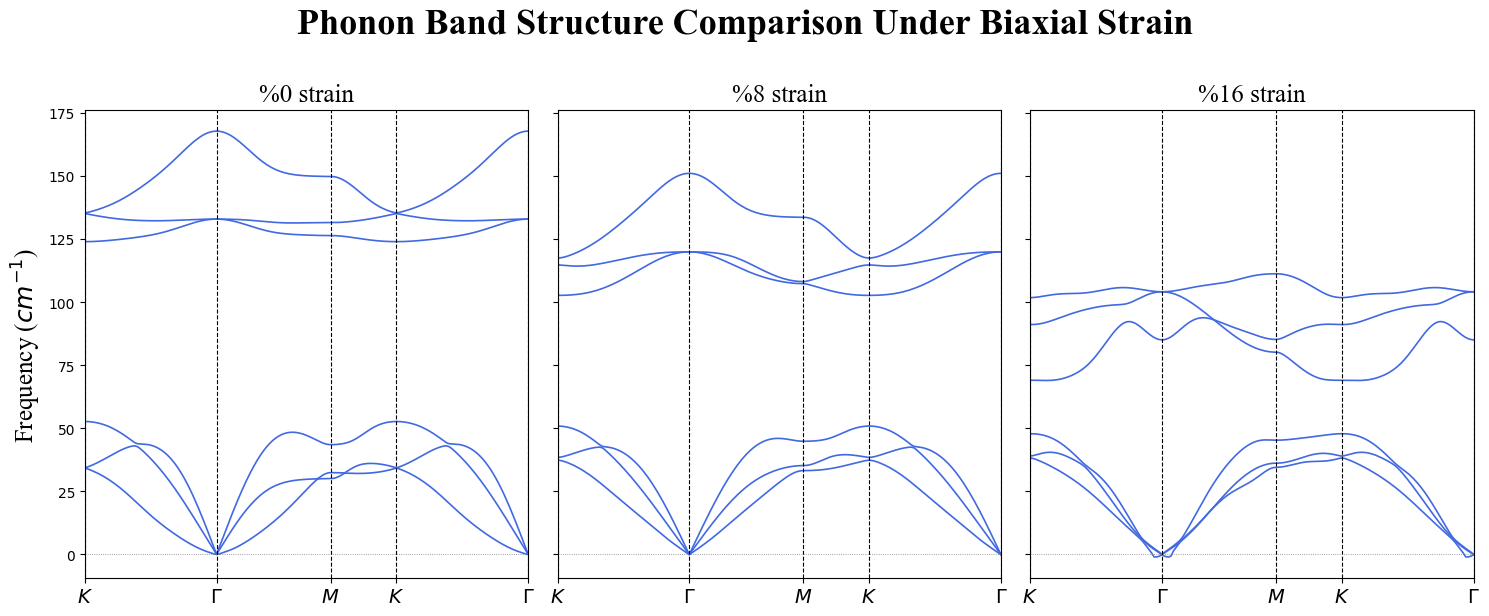

In [7]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

def parse_band_yaml(filepath):
    """Parse phonopy band.yaml and return distances, frequencies, segment_boundaries."""
    with open(filepath, 'r') as f:
        data = yaml.safe_load(f)

    segment_nqpoint = data['segment_nqpoint']

    distances, frequencies = [], []
    for phonon in data['phonon']:
        distances.append(phonon['distance'])
        frequencies.append([band['frequency'] for band in phonon['band']])

    distances   = np.array(distances)
    frequencies = np.array(frequencies)

    idx, segment_boundaries = 0, []
    for seg_nq in segment_nqpoint:
        segment_boundaries.append(distances[idx])
        idx += seg_nq
    segment_boundaries.append(distances[-1])

    return distances, frequencies, segment_boundaries


# ── Configuration ────────────────────────────────────────────────────────────

FILES  = ["biaxial-0-ph/band.yaml", "biaxial-8-ph/band.yaml", "biaxial-16-ph/band.yaml"]
TITLES = ["%0 strain", "%8 strain", "%16 strain"]
LABELS = [r'$K$', r'$\Gamma$', r'$M$',r'$K$',r'$\Gamma$']

# ── Main ─────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    n = len(FILES)
    datasets = [parse_band_yaml(f) for f in FILES]

    # Shared y-range across all panels
    all_freqs = np.concatenate([d[1].ravel() for d in datasets])
    ymin, ymax = all_freqs.min(), all_freqs.max()
    ypad = (ymax - ymin) * 0.05

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]   # keep it iterable for the loop below

    for i, (ax, (distances, frequencies, seg_bounds)) in enumerate(zip(axes, datasets)):

        for band in frequencies.T:          # iterate over columns = bands
            ax.plot(distances, band, color='royalblue', linewidth=1.2)

        for xb in seg_bounds:
            ax.axvline(x=xb, color='black', linewidth=0.8, linestyle='--')
        ax.axhline(y=0, color='gray', linewidth=0.6, linestyle=':')

        ax.set_xlim(distances[0], distances[-1])
        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.set_xticks(seg_bounds)
        ax.set_xticklabels(LABELS,fontsize=14, fontname="Times New Roman", fontweight="bold")
        ax.set_title(TITLES[i],fontsize=18, fontname="Times New Roman")
        if i == 0:
            ax.set_ylabel("Frequency ($cm^{-1}$)",fontsize=18, fontname="Times New Roman")

    fig.suptitle("Phonon Band Structure Comparison Under Biaxial Strain", y=1.02, fontsize=26, fontname="Times New Roman", fontweight="bold")
    plt.tight_layout()
    plt.savefig("phonon_bands_comparison-biaxial.png", dpi=150, bbox_inches='tight')
    plt.show()

Saved.


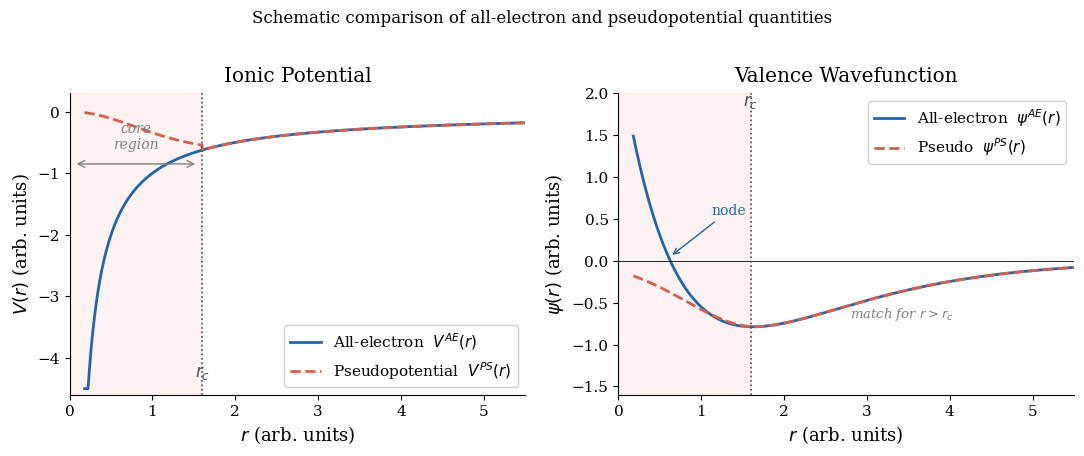

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── aesthetics ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

r_c = 1.6          # core cutoff radius
r   = np.linspace(0.18, 6.0, 3000)

# ── all-electron wavefunction (2s-like: one node, decays) ─────────────────────
def ae_wavefunction(r, r_c):
    psi = np.exp(-r) * (1 - 1.6 * r) * 2.5
    return psi

# ── pseudo wavefunction (smooth, nodeless inside r_c, matches AE outside) ────
def ps_wavefunction(r, r_c):
    psi_ae = ae_wavefunction(r, r_c)
    val_rc   = ae_wavefunction(np.array([r_c]), r_c)[0]
    dpsi_ae  = np.gradient(psi_ae, r)
    idx_rc   = np.argmin(np.abs(r - r_c))
    slope_rc = dpsi_ae[idx_rc]

    psi_ps = np.where(
        r <= r_c,
        val_rc * np.exp(-0.5 * ((r - r_c) / (0.55 * r_c))**2)
        * (1 + 0.18 * (r - r_c) / r_c),
        psi_ae
    )
    return psi_ps

# ── potentials ────────────────────────────────────────────────────────────────
V_ae = -1.0 / r                        # diverges as -Z/r
V_ae = np.clip(V_ae, -4.5, 0)

def V_pseudo(r, r_c):
    return np.where(
        r <= r_c,
        -1.0 / r_c * (1 - np.exp(-((r / (0.7 * r_c))**2))),
        -1.0 / r
    )

V_ps = V_pseudo(r, r_c)

psi_ae = ae_wavefunction(r, r_c)
psi_ps = ps_wavefunction(r, r_c)

# ── figure layout ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.subplots_adjust(wspace=0.35)

colors = {
    "ae":   "#2166ac",
    "ps":   "#d6604d",
    "rc":   "#4d4d4d",
    "fill": "#fddbc7",
}

# ─────────────────────────────────────────────────────────────────────────────
# LEFT panel: potentials
# ─────────────────────────────────────────────────────────────────────────────
ax1.plot(r, V_ae, color=colors["ae"], lw=2.0, label=r"All-electron  $V^{AE}(r)$")
ax1.plot(r, V_ps, color=colors["ps"], lw=2.0, linestyle="--",
         label=r"Pseudopotential  $V^{PS}(r)$")
ax1.axvline(r_c, color=colors["rc"], lw=1.2, linestyle=":", zorder=3)
ax1.axvspan(0, r_c, alpha=0.08, color=colors["ps"])

ax1.set_xlim(0, 5.5)
ax1.set_ylim(-4.6, 0.3)
ax1.set_xlabel(r"$r$ (arb. units)")
ax1.set_ylabel(r"$V(r)$ (arb. units)")
ax1.set_title("Ionic Potential", pad=8)

ax1.annotate(r"$r_c$", xy=(r_c, -4.3), ha="center", fontsize=12,
             color=colors["rc"])
ax1.annotate("core\nregion", xy=(r_c / 2, -0.6), ha="center",
             fontsize=10, color="gray", style="italic")
ax1.annotate("", xy=(0.05, -0.85), xytext=(r_c - 0.05, -0.85),
             arrowprops=dict(arrowstyle="<->", color="gray", lw=1.0))

ax1.legend(loc="lower right", framealpha=0.9)
ax1.spines[["top", "right"]].set_visible(False)

# ─────────────────────────────────────────────────────────────────────────────
# RIGHT panel: wavefunctions
# ─────────────────────────────────────────────────────────────────────────────
ax2.plot(r, psi_ae, color=colors["ae"], lw=2.0,
         label=r"All-electron  $\psi^{AE}(r)$")
ax2.plot(r, psi_ps, color=colors["ps"], lw=2.0, linestyle="--",
         label=r"Pseudo  $\psi^{PS}(r)$")
ax2.axvline(r_c, color=colors["rc"], lw=1.2, linestyle=":", zorder=3)
ax2.axvspan(0, r_c, alpha=0.08, color=colors["ps"])
ax2.axhline(0, color="k", lw=0.6, linestyle="-")

ax2.set_xlim(0, 5.5)
ax2.set_ylim(-1.6, 2.0)
ax2.set_xlabel(r"$r$ (arb. units)")
ax2.set_ylabel(r"$\psi(r)$ (arb. units)")
ax2.set_title("Valence Wavefunction", pad=8)

ax2.annotate(r"$r_c$", xy=(r_c, 1.85), ha="center", fontsize=12,
             color=colors["rc"])

# annotate node of AE wavefunction
node_r = 1.0 / 1.6
ax2.annotate("node", xy=(node_r, 0.05), xytext=(node_r + 0.5, 0.55),
             arrowprops=dict(arrowstyle="->", color=colors["ae"], lw=1.0),
             color=colors["ae"], fontsize=10)

# annotate matching region
ax2.annotate("match for $r > r_c$", xy=(2.8, ae_wavefunction(np.array([2.8]), r_c)[0] - 0.15),
             fontsize=9.5, color="gray", style="italic")

ax2.legend(loc="upper right", framealpha=0.9)
ax2.spines[["top", "right"]].set_visible(False)

# ── shared caption arrow showing smooth vs oscillatory ───────────────────────
fig.suptitle(
    "Schematic comparison of all-electron and pseudopotential quantities",
    fontsize=12, y=1.01
)
plt.savefig("pseudo1.png",bbox_inches="tight", dpi=300)
plt.tight_layout()
print("Saved.")

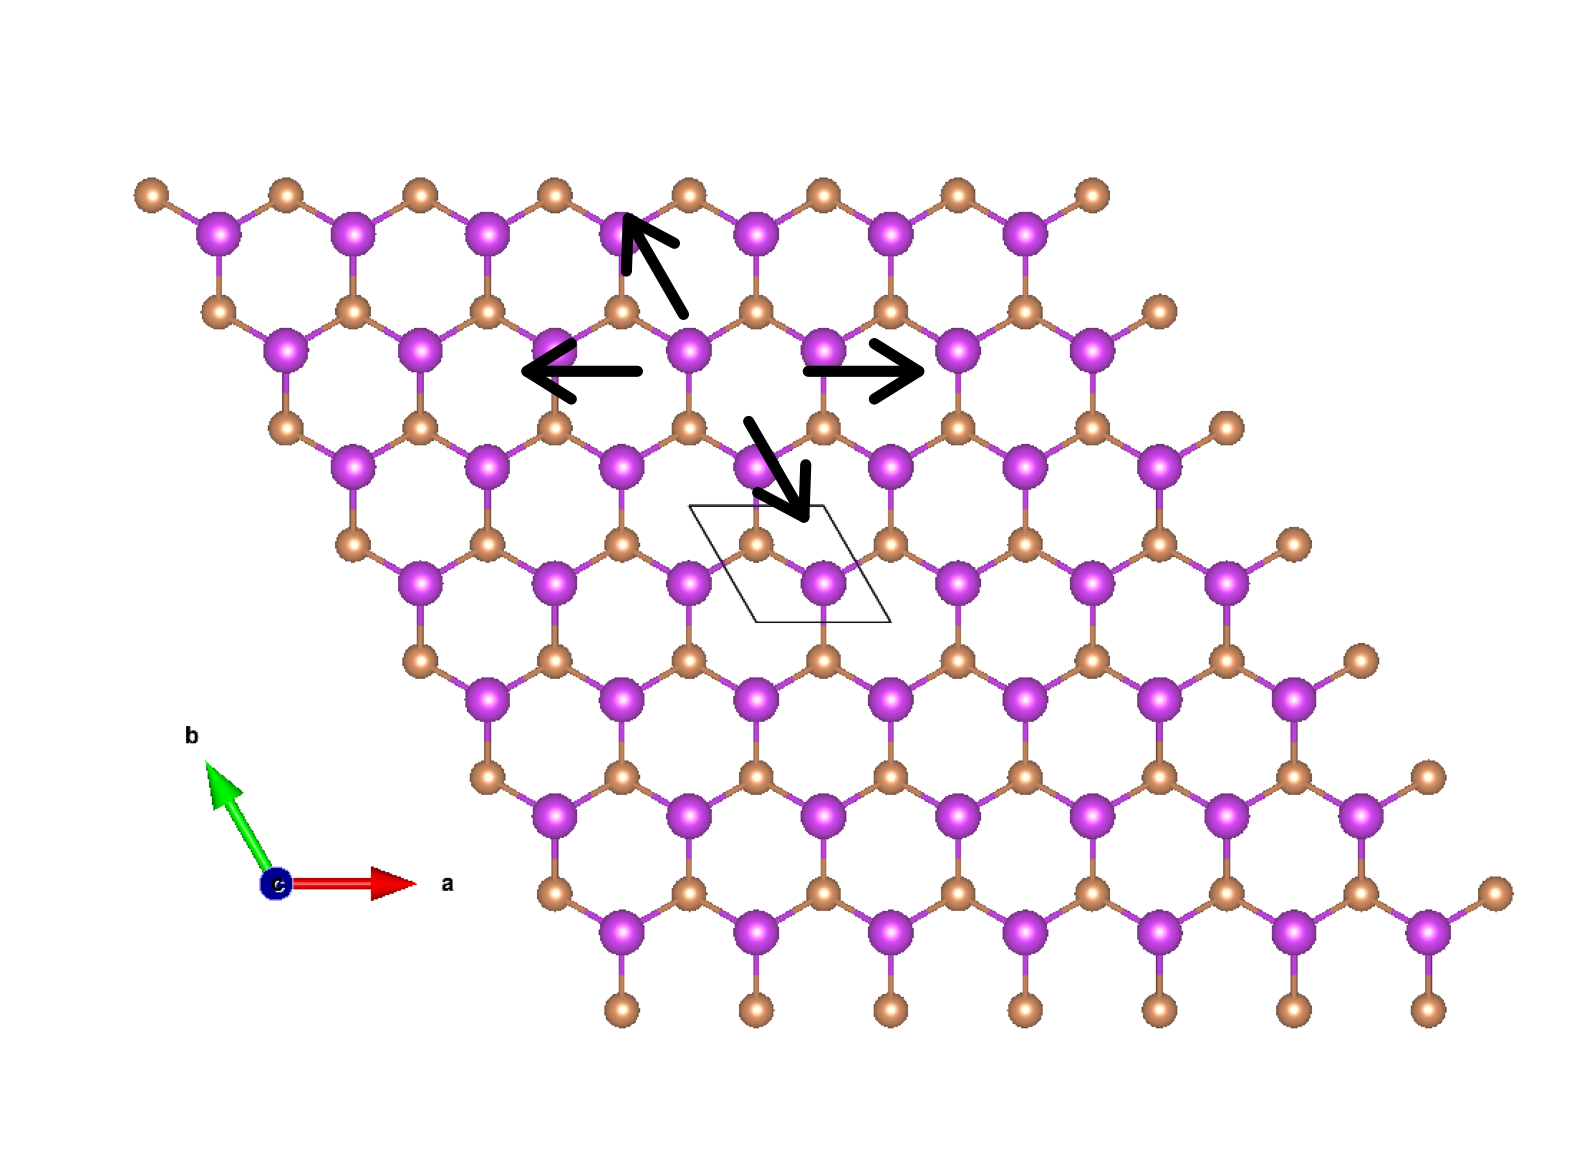

Saved → BiSb_monolayer.png


In [26]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

im1 = Image.open("a.png")
im2 = Image.open("b.png")

fig, ax = plt.subplots(1, 1, figsize=(5, 3), dpi=400)

ax.imshow(im1)
ax.axis("off")


def draw_arrow(ax, start, angle_deg, color="black", lw=2, length=100,
               head_width=5, head_length=8):
    """
    Draw a single-headed arrow from a start point in a given direction.

    Parameters
    ----------
    ax         : matplotlib Axes
    start      : (x, y) tuple — starting point in pixel coordinates
    angle_deg  : direction angle in degrees (0=right, 90=up, 180=left, 270=down)
    color      : arrow color
    lw         : line width
    length     : fixed arrow length in pixels
    head_width : width of the arrowhead
    head_length: length of the arrowhead
    """
    x1, y1 = start
    angle_rad = np.radians(angle_deg)
    x2 = x1 + length * np.cos(angle_rad)
    y2 = y1 - length * np.sin(angle_rad)  # minus because y-axis is flipped in image coords

    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                xycoords="data", textcoords="data",
                arrowprops=dict(
                    arrowstyle=f"->,head_width={head_width/10:.2f},head_length={head_length/10:.2f}",
                    color=color,
                    lw=lw
                ))

# ── Image dimensions ────────────────────────────────────────────────────────
cx, cy = w1 * 0.56, h1 * 0.49
draw_arrow(ax, (cx, cy), 0)    # →

cx, cy = w1 * 0.45, h1 * 0.49
draw_arrow(ax, (cx, cy), 180)  # ←

cx, cy = w1 * 0.48, h1 * 0.42
draw_arrow(ax, (cx, cy), 120)   # ↑

cx, cy = w1 * 0.52, h1 * 0.55
draw_arrow(ax, (cx, cy), 300)  # ↓

plt.tight_layout()
plt.savefig("biaxial-application.png", bbox_inches="tight", dpi=400)
plt.show()
print("Saved → BiSb_monolayer.png")

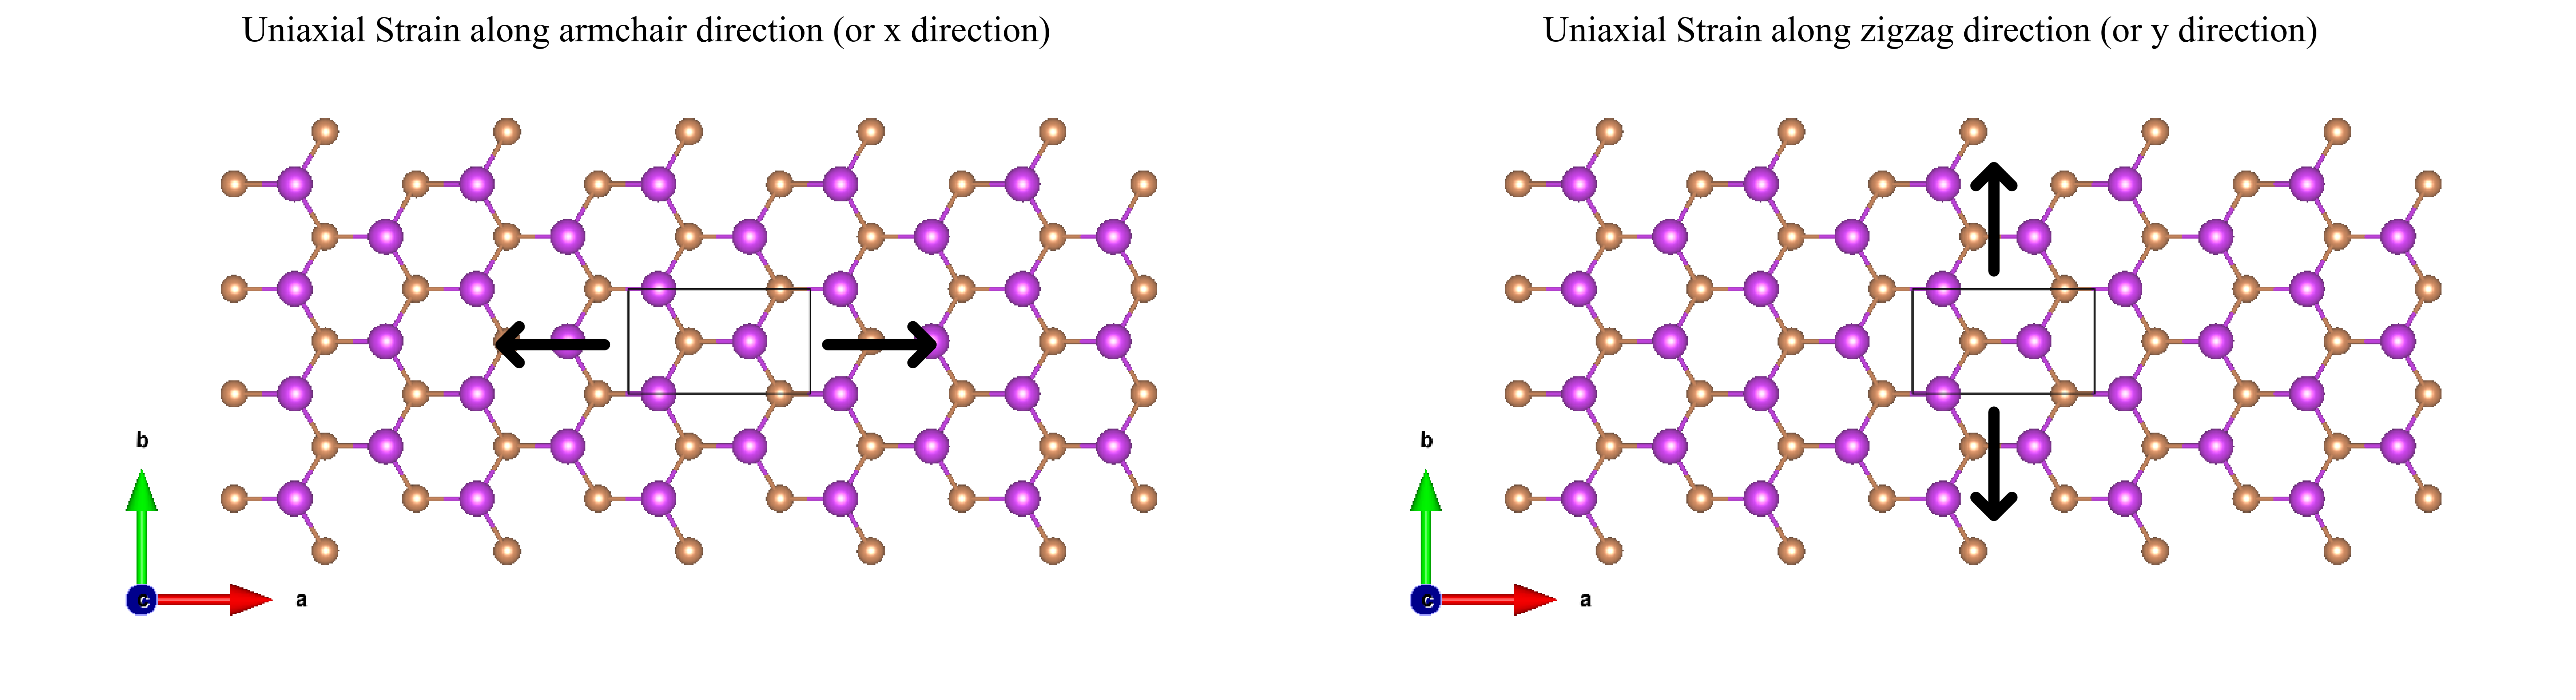

Saved → BiSb_monolayer.png


In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

im1 = Image.open("tetragonal.png")

fig, ax = plt.subplots(1, 2, figsize=(16, 8), dpi=400)

ax[0].imshow(im1)
ax[1].imshow(im1)
ax[0].axis("off")
ax[1].axis("off")


def draw_arrow(ax, start, angle_deg, color="black", lw=5, length=90,
               head_width=8, head_length=8):
    """
    Draw a single-headed arrow from a start point in a given direction.

    Parameters
    ----------
    ax         : matplotlib Axes
    start      : (x, y) tuple — starting point in pixel coordinates
    angle_deg  : direction angle in degrees (0=right, 90=up, 180=left, 270=down)
    color      : arrow color
    lw         : line width
    length     : fixed arrow length in pixels
    head_width : width of the arrowhead
    head_length: length of the arrowhead
    """
    x1, y1 = start
    angle_rad = np.radians(angle_deg)
    x2 = x1 + length * np.cos(angle_rad)
    y2 = y1 - length * np.sin(angle_rad)  # minus because y-axis is flipped in image coords

    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                xycoords="data", textcoords="data",
                arrowprops=dict(
                    arrowstyle=f"->,head_width={head_width/10:.2f},head_length={head_length/10:.2f}",
                    color=color,
                    lw=lw
                ))


h1, w1 = np.array(im1).shape[:2]

# ── Image dimensions ────────────────────────────────────────────────────────
cx, cy = w1 * 0.64, h1 * 0.46
draw_arrow(ax[0], (cx, cy), 0)    # →

cx, cy = w1 * 0.47, h1 * 0.46
draw_arrow(ax[0], (cx, cy), 180)  # ←

cx, cy = w1 * 0.55, h1 * 0.35
draw_arrow(ax[1], (cx, cy), 90)   # ↑

cx, cy = w1 * 0.55, h1 * 0.56
draw_arrow(ax[1], (cx, cy), 270)  # ↓

ax[0].set_title("Uniaxial Strain along armchair direction (or x direction)",fontsize = 16, fontname='Times New Roman')
ax[1].set_title("Uniaxial Strain along zigzag direction (or y direction)",fontsize = 16, fontname='Times New Roman')
plt.tight_layout()
plt.savefig("uniaxial-application.png", bbox_inches="tight", dpi=400)
plt.show()
print("Saved → BiSb_monolayer.png")